In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

if not os.path.exists('/content/organized_places365/train_samples'):
    !unzip -q "/content/drive/MyDrive/Scene Classification/organized_places365.zip" -d "/content/organized_places365"
    print("Extraction complete!")
else:
    print("Dataset is already extracted!")

Mounted at /content/drive
Extraction complete!


In [2]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"{device}")

cuda


In [3]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
print("Transformations successfully defined.")

Transformations successfully defined.


In [4]:

train_dir = '/content/organized_places365/train_samples'
valid_dir = '/content/organized_places365/valid_samples'

train_data = datasets.ImageFolder(train_dir, transform=train_transform)
valid_data = datasets.ImageFolder(valid_dir, transform=eval_transform)

# the DataLoaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False)

print(f"Loaded")

Loaded


In [5]:
import torch.nn as nn
import torch.optim as optim

class SceneClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Load the DINOv2 model directly from Meta
        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')

        # Freeze
        for param in self.backbone.parameters():
            param.requires_grad = False

        # MLP
        self.head = nn.Sequential(
            nn.Linear(384, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        output = self.head(features)
        return output

# move it to the GPU
model = SceneClassifier(num_classes=len(train_data.classes)).to(device)
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, weight_decay=0.05)

print("Model successfully built")

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 311MB/s]


Model successfully built


In [ ]:
import time

MAX_EPOCHS = 15
PATIENCE = 4
epochs_without_improvement = 0
best_accuracy = 0.0

print(f"Starting training process (Max {MAX_EPOCHS} Epochs)...\n")

for epoch in range(MAX_EPOCHS):
    start_time = time.time()


    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        if batch_idx % 100 == 0:
            print(f"Epoch {epoch+1} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_train_acc = (train_correct / train_total) * 100


    # VALIDATION PHASE

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(valid_loader.dataset)
    epoch_val_acc = (val_correct / val_total) * 100
    elapsed_time = time.time() - start_time

    print(f"\nEPOCH {epoch+1} COMPLETE ({elapsed_time:.0f}s) ")
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
    print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.2f}%")


    # EARLY STOPPING

    if epoch_val_acc > best_accuracy:
        best_accuracy = epoch_val_acc
        epochs_without_improvement = 0
        save_path = "/content/drive/MyDrive/Scene Classification/best_scene_classifier.pth"
        torch.save(model.state_dict(), save_path)
        print(f"New best validation accuracy! Saved model weights.")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s).")

        if epochs_without_improvement >= PATIENCE:
            print(f"\nEarly Stopping Applied! Halting training to prevent overfitting.")
            break

    print("-" * 50 + "\n")

print(f"Training completed! Peak validation accuracy: {best_accuracy:.2f}%")

Starting training process (Max 15 Epochs)...

Epoch 1 | Batch 0/685 | Loss: 6.0463
Epoch 1 | Batch 100/685 | Loss: 3.9696
Epoch 1 | Batch 200/685 | Loss: 3.3680
Epoch 1 | Batch 300/685 | Loss: 3.0166
Epoch 1 | Batch 400/685 | Loss: 2.9305
Epoch 1 | Batch 500/685 | Loss: 2.7831
Epoch 1 | Batch 600/685 | Loss: 2.5934

EPOCH 1 COMPLETE (247s) 
Train Loss: 3.2823 | Train Acc: 29.06%
Val Loss:   2.4500 | Val Acc:   41.12%
New best validation accuracy! Saved model weights.
--------------------------------------------------

Epoch 2 | Batch 0/685 | Loss: 1.8653
Epoch 2 | Batch 100/685 | Loss: 2.6421
Epoch 2 | Batch 200/685 | Loss: 1.8816
Epoch 2 | Batch 300/685 | Loss: 2.5990
Epoch 2 | Batch 400/685 | Loss: 2.2503
Epoch 2 | Batch 500/685 | Loss: 1.9815
Epoch 2 | Batch 600/685 | Loss: 1.8586

EPOCH 2 COMPLETE (245s) 
Train Loss: 2.3807 | Train Acc: 40.14%
Val Loss:   2.4492 | Val Acc:   42.59%
New best validation accuracy! Saved model weights.
--------------------------------------------------

In [ ]:
import torch

model.load_state_dict(torch.load('/content/drive/MyDrive/Scene Classification/best_scene_classifier.pth', map_location=device))
model.eval()

top1_correct = 0
top5_correct = 0
total_images = 0

print("validation set for Top-1 and Top-5 Accuracy...")

with torch.no_grad():
    for images, labels in valid_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        # --- TOP-1 ACCURACY ---
        _, predicted = torch.max(outputs, 1)
        top1_correct += (predicted == labels).sum().item()

        # --- TOP-5 ACCURACY ---
        _, top5_preds = torch.topk(outputs, 5, dim=1)

        for i in range(labels.size(0)):
            if labels[i] in top5_preds[i]:
                top5_correct += 1

        total_images += labels.size(0)

# Calculate final percentages
top1_acc = (top1_correct / total_images) * 100
top5_acc = (top5_correct / total_images) * 100

print("-" * 40)
print(f"Total Images Evaluated: {total_images}")
print(f"Final Top-1 Accuracy: {top1_acc:.2f}%")
print(f"Final Top-5 Accuracy: {top5_acc:.2f}%")

validation set for Top-1 and Top-5 Accuracy...
----------------------------------------
Total Images Evaluated: 7298
Final Top-1 Accuracy: 43.68%
Final Top-5 Accuracy: 76.65%


In [ ]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader


test_dir = '/content/organized_places365/test_samples'
test_data = datasets.ImageFolder(test_dir, transform=eval_transform)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Loaded {len(test_data)} test images")

# Load model
model.load_state_dict(torch.load('/content/drive/MyDrive/Scene Classification/best_scene_classifier.pth', map_location=device))
model.eval()

top1_correct = 0
top5_correct = 0
total_images = 0

print("test set for Top-1 and Top-5 Accuracy...\n")

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        # --- TOP-1 ---
        _, predicted = torch.max(outputs, 1)
        top1_correct += (predicted == labels).sum().item()

        # --- TOP-5 ---
        _, top5_preds = torch.topk(outputs, 5, dim=1)
        for i in range(labels.size(0)):
            if labels[i] in top5_preds[i]:
                top5_correct += 1

        total_images += labels.size(0)

# Calculate final percentages
test_top1_acc = (top1_correct / total_images) * 100
test_top5_acc = (top5_correct / total_images) * 100

print("-" * 40)
print(f"TOP-1 ACCURACY: {test_top1_acc:.2f}%")
print(f"TOP-5 ACCURACY: {test_top5_acc:.2f}%")

Loaded 7302 test images
test set for Top-1 and Top-5 Accuracy...

----------------------------------------
TOP-1 ACCURACY: 43.18%
TOP-5 ACCURACY: 76.31%


In [ ]:
!pip install -q thop
from thop import profile

dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Run the profiler
macs, params = profile(model, inputs=(dummy_input, ))

# Convert MACs to GFLOPs
gflops = (macs * 2) / 1e9

print("-" * 40)
print(f"Total Parameters: {params:,}")
print(f"Total Math Required: {gflops:.3f} GFLOPs")

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.normalization.LayerNorm'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
----------------------------------------
Total Parameters: 21,878,714.0
Total Math Required: 11.050 GFLOPs


In [ ]:
from thop import profile
import torch

dummy_features = torch.randn(1, 384).to(device)

# Run the profiler
macs_head, params_head = profile(model.head, inputs=(dummy_features, ))

# Convert MACs to GFLOPs
gflops_head = (macs_head * 2) / 1e9
mflops_head = (macs_head * 2) / 1e6

print("-" * 40)
print(f"MLP Head Parameters: {params_head:,}")
print(f"MLP Head Math: {gflops_head:.6f} GFLOPs ({mflops_head:.2f} MFLOPs)")

[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
----------------------------------------
MLP Head Parameters: 358,202.0
MLP Head Math: 0.000715 GFLOPs (0.71 MFLOPs)


In [ ]:
import time
import numpy as np

dummy_input = torch.randn(1, 3, 224, 224).to(device)
model.eval()

print("Warming up the T4 GPU...")
with torch.no_grad():
    for _ in range(50):
        _ = model(dummy_input)

# MEASURE LATENCY
print("Measuring Latency...")
latencies = []

with torch.no_grad():
    for _ in range(100):

        torch.cuda.synchronize()
        start_time = time.time()

        # Process the image
        _ = model(dummy_input)

        torch.cuda.synchronize()
        end_time = time.time()

        # Convert seconds to milliseconds (ms)
        latencies.append((end_time - start_time) * 1000)

# Calculate the average
average_latency = np.mean(latencies)

print("-" * 40)
print(f"Average Inference Latency: {average_latency:.2f} ms per image")

Warming up the T4 GPU...
Measuring Latency...
----------------------------------------
Average Inference Latency: 7.87 ms per image


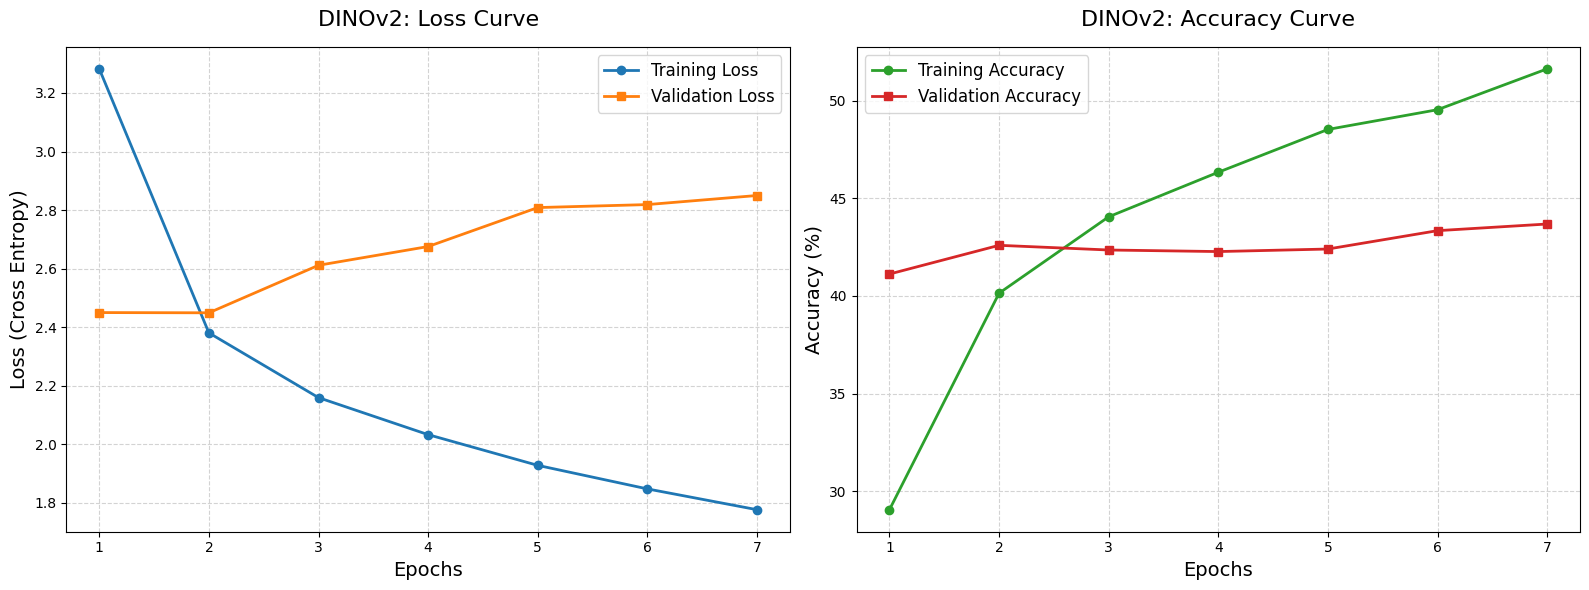

In [9]:
import matplotlib.pyplot as plt

epochs = list(range(1, 8))
train_loss = [3.2823, 2.3807, 2.1595, 2.0331, 1.9282, 1.8478, 1.7768]
val_loss =   [2.4500, 2.4492, 2.6115, 2.6755, 2.8086, 2.8188, 2.8498]
train_acc =  [29.06, 40.14, 44.05, 46.33, 48.52, 49.53, 51.62]
val_acc =    [41.12, 42.59, 42.35, 42.27, 42.40, 43.34, 43.68]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Loss Curve ---
ax1.plot(epochs, train_loss, marker='o', markersize=6, linestyle='-', linewidth=2, label='Training Loss', color='#1f77b4')
ax1.plot(epochs, val_loss, marker='s', markersize=6, linestyle='-', linewidth=2, label='Validation Loss', color='#ff7f0e')
ax1.set_title('DINOv2: Loss Curve', fontsize=16, pad=15)
ax1.set_xlabel('Epochs', fontsize=14)
ax1.set_ylabel('Loss (Cross Entropy)', fontsize=14)
ax1.set_xticks(epochs)
ax1.grid(True, linestyle='--', color='lightgrey')
ax1.legend(fontsize=12)

# --- Plot 2: Accuracy Curve ---
ax2.plot(epochs, train_acc, marker='o', markersize=6, linestyle='-', linewidth=2, label='Training Accuracy', color='#2ca02c')
ax2.plot(epochs, val_acc, marker='s', markersize=6, linestyle='-', linewidth=2, label='Validation Accuracy', color='#d62728')
ax2.set_title('DINOv2: Accuracy Curve', fontsize=16, pad=15)
ax2.set_xlabel('Epochs', fontsize=14)
ax2.set_ylabel('Accuracy (%)', fontsize=14)
ax2.set_xticks(epochs)
ax2.grid(True, linestyle='--', color='lightgrey')
ax2.legend(fontsize=12)

plt.tight_layout()
plt.show()